In [2]:
# =============================================================
# CÀI ĐẶT MÔI TRƯỜNG
# =============================================================
import sys
import matplotlib
import matplotlib.pyplot as plt
import warnings

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

print("Môi trường đã được cài đặt thành công!")
print(f"Python version: {sys.version}")

Môi trường đã được cài đặt thành công!
Python version: 3.10.0 (v3.10.0:b494f5935c, Oct  4 2021, 14:59:19) [Clang 12.0.5 (clang-1205.0.22.11)]


# CLUSTERING TRÊN RFM FEATURES

## Mục tiêu

- Tiền xử lý dữ liệu RFM bằng StandardScaler trước khi clustering.
- Chọn số cụm K tối ưu bằng Elbow method (Inertia) và Silhouette Score, khảo sát K từ 2 đến 10.
- Triển khai và đánh giá 2 mô hình: **KMeans** và **GaussianMixture (GMM)**.
- So sánh hiệu suất 2 mô hình bằng Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index.

## Cài đặt Thư viện

In [3]:
import numpy as np
import pandas as pd
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
# ⚠️ BẮT BUỘC: Phải khai báo class này trước khi load joblib
class PercentileCapper(BaseEstimator, TransformerMixin):
    def __init__(self, upper_quantile=0.99):
        self.upper_quantile = upper_quantile
        self.upper_bounds_ = {}
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self
    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(upper=self.upper_bounds_[col])
        return X_df.values
# Bây giờ mới load joblib (Python đã hiểu PercentileCapper rồi)
print("Đang load Pipeline Tiền Xử Lý dữ liệu gom cụm...")
pipeline_clustering = joblib.load('/Users/dieplacyenphuong/BigData-Final-Project/Models/rfm_pipeline_preprocessor.joblib')
print("✅ Load Pipeline thành công!")

Đang load Pipeline Tiền Xử Lý dữ liệu gom cụm...
✅ Load Pipeline thành công!



## Load Dữ liệu RFM

File `rfm_dataset.parquet` được tạo từ pipeline của Member 1.  
Chỉnh lại `RFM_PATH` cho đúng đường dẫn máy bạn trước khi chạy.

In [4]:
# ========================================================
# ⚠️ CHỈNH LẠI ĐƯỜNG DẪN NÀY CHO ĐÚNG MÁY BẠN
# ========================================================

# Nếu chạy trên Kaggle:
# RFM_PATH = "/kaggle/working/processed_data/week1/rfm_dataset.parquet"

# Nếu chạy trên máy local (VSCode) từ Notebooks folder:
RFM_PATH = "../Data/Raw/rfm_dataset.parquet"

# Load dữ liệu
rfm = pd.read_parquet(RFM_PATH)

print(f"✅ Loaded RFM dataset: {rfm.shape[0]:,} khách hàng | {rfm.shape[1]} cột")
print(f"\nCác cột: {rfm.columns.tolist()}")
print("\nMẫu dữ liệu:")
rfm.head()

✅ Loaded RFM dataset: 96,096 khách hàng | 3 cột

Các cột: ['Recency', 'Frequency', 'Monetary']

Mẫu dữ liệu:


,Recency,Frequency,Monetary
0,161,1,141.90
1,164,1,27.19
2,586,1,86.22
3,370,1,43.62
4,337,1,196.89


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [6]:
# Thống kê mô tả RFM
print("📋 Thống kê mô tả RFM:")
rfm_desc = rfm[['Recency', 'Frequency', 'Monetary']].describe().T[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
]
print(rfm_desc.to_string())

📋 Thống kê mô tả RFM:
             count        mean         std  min     25%     50%       75%        max
Recency    96096.0  288.735691  153.414676  1.0  164.00  269.00  398.0000     773.00
Frequency  96096.0    1.034809    0.214384  1.0    1.00    1.00    1.0000      17.00
Monetary   96096.0  213.023712  640.917083  0.0   63.99  113.15  202.7325  109312.64



## Bước 1: Tiền xử lý — Xử lý Outlier và StandardScaler

Theo yêu cầu đồ án: **StandardScaler trên RFM trước khi clustering**.  
Trước đó, cần xử lý outlier cực đoan (Monetary có max=109,312 trong khi 75th percentile chỉ là ~202) để tránh ảnh hưởng đến kết quả phân cụm.

In [7]:
# ---- Step 1: Cap outlier tại 99th percentile ----
rfm_clean = rfm[['Recency', 'Frequency', 'Monetary']].copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    upper = rfm_clean[col].quantile(0.99)
    rfm_clean[col] = rfm_clean[col].clip(upper=upper)

print(" Đã xử lý outlier (clip tại 99th percentile)")

# ---- Step 2: StandardScaler ----
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)

print(f" Đã chuẩn hóa dữ liệu bằng StandardScaler")
print(f"   Shape sau khi scale: {rfm_scaled.shape}")
print(f"   Mean sau scale (gần 0): {rfm_scaled.mean(axis=0).round(6)}")
print(f"   Std sau scale (gần 1):  {rfm_scaled.std(axis=0).round(6)}")

 Đã xử lý outlier (clip tại 99th percentile)
 Đã chuẩn hóa dữ liệu bằng StandardScaler
   Shape sau khi scale: (96096, 3)
   Mean sau scale (gần 0): [-0.  0. -0.]
   Std sau scale (gần 1):  [1. 1. 1.]


In [8]:

# ============================================================
# 🔍 PHÂN TÍCH CHI TIẾT: DỮ LIỆU TRƯỚC/SAU XỬ LÝ
# ============================================================

print("=" * 80)
print("📊 PHẦN 2: KHÁM PHÁ DỮ LIỆU VÀ PHÂN TÍCH TIỀN XỬ LÝ")
print("=" * 80)

# ---- Bước 1: So sánh dữ liệu ĐỌC VÀO vs SAU CLP OUTLIER ----
rfm_original = rfm[['Recency', 'Frequency', 'Monetary']].copy()

print("\n🔸 BƯỚC 1: DỮ LIỆU ĐỌC VÀO (Trước xử lý outlier)")
print("-" * 80)
print("Thống kê mô tả dữ liệu NGUYÊN BẢN từ file parquet:")
print(rfm_original.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].to_string())

print(f"\nNhận xét dữ liệu nguyên bản:")
for col in ['Recency', 'Frequency', 'Monetary']:
    mean_val = rfm_original[col].mean()
    std_val = rfm_original[col].std()
    min_val = rfm_original[col].min()
    max_val = rfm_original[col].max()
    ratio = max_val / std_val if std_val > 0 else 0
    print(f"  • {col:12} — Mean={mean_val:10.2f}  Std={std_val:10.2f}  Max={max_val:12.2f}  (Max/Std={ratio:8.2f})")

print("\n⚠️  PHÁT HIỆN VẤN ĐỀ OUTLIER:")
print(f"  • Monetary Max = {rfm_original['Monetary'].max():.2f}")
print(f"  • Monetary Q75 = {rfm_original['Monetary'].quantile(0.75):.2f}")
print(f"  • Monetary Q99 = {rfm_original['Monetary'].quantile(0.99):.2f}")
print(f"  ➜ Tỷ lệ Max/Q99 = {rfm_original['Monetary'].max() / rfm_original['Monetary'].quantile(0.99):.1f}x")
print(f"  ➜ KẾT LUẬN: Outlier cực đoan! Cần xử lý trước clustering")

# ---- Bước 2: Sau cắt outlier ----
print("\n" + "=" * 80)
print("🔸 BƯỚC 2: DỮ LIỆU SAU XỬ LÝ OUTLIER (Clip tại Q99)")
print("-" * 80)
print("Thống kê mô tả dữ liệu SAU CẮT OUTLIER:")
print(rfm_clean.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].to_string())

print(f"\nNhận xét sau cắt outlier:")
for col in ['Recency', 'Frequency', 'Monetary']:
    before_max = rfm_original[col].max()
    after_max = rfm_clean[col].max()
    percent_change = (1 - after_max/before_max) * 100 if before_max > 0 else 0
    print(f"  • {col:12} — Before Max={before_max:12.2f}  After Max={after_max:12.2f}  (Giảm {percent_change:6.2f}%)")

print("\n✅ HIỆU QUẢ CẮT OUTLIER:")
print(f"  • Monetary Max giảm từ {rfm_original['Monetary'].max():.2f} → {rfm_clean['Monetary'].max():.2f}")
print(f"  • Số khách hàng bị ảnh hưởng: {(rfm_original['Monetary'] != rfm_clean['Monetary']).sum():,} / {len(rfm_clean):,}")
print(f"    (chiếm {(rfm_original['Monetary'] != rfm_clean['Monetary']).sum() / len(rfm_clean) * 100:.2f}%)")


📊 PHẦN 2: KHÁM PHÁ DỮ LIỆU VÀ PHÂN TÍCH TIỀN XỬ LÝ

🔸 BƯỚC 1: DỮ LIỆU ĐỌC VÀO (Trước xử lý outlier)
--------------------------------------------------------------------------------
Thống kê mô tả dữ liệu NGUYÊN BẢN từ file parquet:
             count        mean         std  min     25%     50%       75%        max
Recency    96096.0  288.735691  153.414676  1.0  164.00  269.00  398.0000     773.00
Frequency  96096.0    1.034809    0.214384  1.0    1.00    1.00    1.0000      17.00
Monetary   96096.0  213.023712  640.917083  0.0   63.99  113.15  202.7325  109312.64

Nhận xét dữ liệu nguyên bản:
  • Recency      — Mean=    288.74  Std=    153.41  Max=      773.00  (Max/Std=    5.04)
  • Frequency    — Mean=      1.03  Std=      0.21  Max=       17.00  (Max/Std=   79.30)
  • Monetary     — Mean=    213.02  Std=    640.92  Max=   109312.64  (Max/Std=  170.56)

⚠️  PHÁT HIỆN VẤN ĐỀ OUTLIER:
  • Monetary Max = 109312.64
  • Monetary Q75 = 202.73
  • Monetary Q99 = 1687.60
  ➜ Tỷ lệ Max/Q99 

In [9]:

print("\n" + "=" * 80)
print("🔸 BƯỚC 3: PHÂN TÍCH SCALE VÀ PHÂN PHỐI DỮ LIỆU")
print("-" * 80)

print("\n❓ TẠI SAO CẬN CHUẨN HÓA (StandardScaler) TRƯỚC K-MEANS?")
print("\n→ K-Means dùng khoảng cách Euclidean để tính toán")
print("→ Nếu các cột có scale khác nhau, cột có range lớn hơn sẽ THỐNG TRỊ kết quả")

print("\n📋 SO SÁNH SCALE GIỮA CÁC CỘT (Trước chuẩn hóa):")
print("-" * 80)

comparison_data = []
for col in ['Recency', 'Frequency', 'Monetary']:
    mean = rfm_clean[col].mean()
    std = rfm_clean[col].std()
    min_val = rfm_clean[col].min()
    max_val = rfm_clean[col].max()
    range_val = max_val - min_val
    cv = (std / mean * 100) if mean > 0 else 0  # Coefficient of Variation
    
    comparison_data.append({
        'Cột': col,
        'Mean': f'{mean:.2f}',
        'Std': f'{std:.2f}',
        'Min': f'{min_val:.2f}',
        'Max': f'{max_val:.2f}',
        'Range': f'{range_val:.2f}',
        'CV(%)': f'{cv:.1f}%'
    })
    
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n⚠️  PHÁT HIỆN:")
print(f"  • Recency:   Range = {rfm_clean['Recency'].max() - rfm_clean['Recency'].min():.2f}  (Std = {rfm_clean['Recency'].std():.2f})")
print(f"  • Frequency: Range = {rfm_clean['Frequency'].max() - rfm_clean['Frequency'].min():.2f}  (Std = {rfm_clean['Frequency'].std():.2f})")
print(f"  • Monetary:  Range = {rfm_clean['Monetary'].max() - rfm_clean['Monetary'].min():.2f}  (Std = {rfm_clean['Monetary'].std():.2f})")
print(f"\n  → Std chênh lệch lớn: {rfm_clean['Monetary'].std() / rfm_clean['Recency'].std():.1f}x")
print(f"  ➜ KẾT LUẬN: CẦN CHUẨN HÓA! StandardScaler là lựa chọn đúng.")

print("\n" + "=" * 80)
print("🔸 BƯỚC 4: SAU CHUẨN HÓA (StandardScaler)")
print("-" * 80)

print("\nDữ liệu sau StandardScaler:")
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
print(rfm_scaled_df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].to_string())

print("\n✅ HIỆU QUẢ CHUẨN HÓA:")
print(f"  • Tất cả các cột có Mean ≈ 0  (lý tưởng)")
print(f"  • Tất cả các cột có Std ≈ 1   (lý tưởng)")
print(f"  • Các cột giờ đã có CÙNG scale → K-Means sẽ công bằng")

print("\n" + "=" * 80)
print("✅ KẾT LUẬN BƯỚC TIỀN XỬ LÝ:")
print("-" * 80)
print(f"  1. ✓ Đã kiểm tra outlier      : Cắt tại Q99")
print(f"  2. ✓ Đã chuẩn hóa dữ liệu     : StandardScaler")
print(f"  3. ✓ Dữ liệu sẵn sàng         : Có thể áp dụng K-Means/GMM")
print("=" * 80)



🔸 BƯỚC 3: PHÂN TÍCH SCALE VÀ PHÂN PHỐI DỮ LIỆU
--------------------------------------------------------------------------------

❓ TẠI SAO CẬN CHUẨN HÓA (StandardScaler) TRƯỚC K-MEANS?

→ K-Means dùng khoảng cách Euclidean để tính toán
→ Nếu các cột có scale khác nhau, cột có range lớn hơn sẽ THỐNG TRỊ kết quả

📋 SO SÁNH SCALE GIỮA CÁC CỘT (Trước chuẩn hóa):
--------------------------------------------------------------------------------
      Cột   Mean    Std  Min     Max   Range  CV(%)
  Recency 288.30 152.31 1.00  626.00  625.00  52.8%
Frequency   1.03   0.17 1.00    2.00    1.00  16.9%
 Monetary 193.61 256.64 0.00 1687.60 1687.60 132.6%

⚠️  PHÁT HIỆN:
  • Recency:   Range = 625.00  (Std = 152.31)
  • Frequency: Range = 1.00  (Std = 0.17)
  • Monetary:  Range = 1687.60  (Std = 256.64)

  → Std chênh lệch lớn: 1.7x
  ➜ KẾT LUẬN: CẦN CHUẨN HÓA! StandardScaler là lựa chọn đúng.

🔸 BƯỚC 4: SAU CHUẨN HÓA (StandardScaler)
----------------------------------------------------------------


## Bước 2: Chọn K Tối ưu — Elbow Method và Silhouette Score

Khảo sát K từ 2 đến 10, tính đồng thời:
- **Inertia** (Within-cluster SSE): dùng cho Elbow Method.
- **Silhouette Score**: đo mức độ phân tách giữa các cụm, giá trị từ -1 đến 1, càng gần 1 càng tốt.

In [10]:
# ---- Khảo sát K = 2 đến 10 ----
K_RANGE = range(2, 11)

inertia_list    = []
silhouette_list = []

print("🔄 Đang tính Inertia + Silhouette Score cho K = 2..10...")
print(f"{'K':>4} {'Inertia':>14} {'Silhouette':>12}")
print("-" * 34)

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    labels = km.fit_predict(rfm_scaled)
    inertia_list.append(km.inertia_)

    # sample_size để tính nhanh hơn với dataset lớn
    sil = silhouette_score(rfm_scaled, labels, sample_size=10000, random_state=42)
    silhouette_list.append(sil)

    print(f"{k:>4} {km.inertia_:>14,.2f} {sil:>12.4f}")

print("\n Hoàn thành!")

🔄 Đang tính Inertia + Silhouette Score cho K = 2..10...
   K        Inertia   Silhouette
----------------------------------
   2     190,467.52       0.7486
   3     124,427.48       0.4430
   4      67,295.35       0.4919
   5      52,584.91       0.4295
   6      40,915.30       0.4521
   7      36,351.94       0.4511
   8      31,809.01       0.3890
   9      27,792.87       0.4010
  10      24,788.66       0.4095

 Hoàn thành!


**Hình IV.2. Elbow Plot và Silhouette Score cho KMeans trên RFM**

## 📊 SO SÁNH: TIỀN XỬ LÝ CÓ ẢNH HƯỞNG ĐẾN KẾT QUẢ KHÔNG?

Chúng ta sẽ so sánh K-Means trên dữ liệu **gốc (raw)** vs **đã xử lý (scaled)** để thấy rõ ảnh hưởng.

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import pandas as pd

print("=" * 80)
print("SO SÁNH K-MEANS TRÊN DỮ LIỆU RAW vs SCALED")
print("=" * 80)

# ---- KMeans trên RAW DATA ----
print("\n🔴 SỬ DỤNG DỮ LIỆU GỐC (RAW - KHÔNG CHUẨN HÓA):")
print("-" * 80)

km_raw = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
labels_raw = km_raw.fit_predict(rfm_clean)  # rfm_clean là dữ liệu gốc

sil_raw = silhouette_score(rfm_clean, labels_raw, sample_size=10000, random_state=42)
db_raw = davies_bouldin_score(rfm_clean, labels_raw)

print(f"Inertia (raw):              {km_raw.inertia_:>20,.2f}")
print(f"Silhouette Score (raw):     {sil_raw:>20.4f}")
print(f"Davies-Bouldin Index (raw): {db_raw:>20.4f}")
print(f"  ↳ Thấp hơn = Tốt hơn")

print("\n📊 Trung bình Cluster (RAW):")
for i in range(2):
    cluster_data = rfm_clean[labels_raw == i]
    print(f"  Cluster {i}: R={cluster_data['Recency'].mean():>8.2f}, F={cluster_data['Frequency'].mean():>8.2f}, M={cluster_data['Monetary'].mean():>10.2f}")

# ---- KMeans trên SCALED DATA ----
print("\n🟢 SỬ DỤNG DỮ LIỆU ĐÃ CHUẨN HÓA (SCALED):")
print("-" * 80)

km_scaled = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
labels_scaled = km_scaled.fit_predict(rfm_scaled)

sil_scaled = silhouette_score(rfm_scaled, labels_scaled, sample_size=10000, random_state=42)
db_scaled = davies_bouldin_score(rfm_scaled, labels_scaled)

print(f"Inertia (scaled):              {km_scaled.inertia_:>20,.2f}")
print(f"Silhouette Score (scaled):     {sil_scaled:>20.4f}")
print(f"Davies-Bouldin Index (scaled): {db_scaled:>20.4f}")
print(f"  ↳ Thấp hơn = Tốt hơn")

print("\n📊 Trung bình Cluster (SCALED):")
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
for i in range(2):
    cluster_data = rfm_scaled_df[labels_scaled == i]
    print(f"  Cluster {i}: R={cluster_data['Recency'].mean():>8.2f}, F={cluster_data['Frequency'].mean():>8.2f}, M={cluster_data['Monetary'].mean():>10.2f}")

# ---- SO SÁNH ----
print("\n" + "=" * 80)
print("📈 KẾT QUẢ SO SÁNH:")
print("=" * 80)

print(f"\n1️⃣  SILHOUETTE SCORE (càng cao càng tốt):")
print(f"   Raw:    {sil_raw:>8.4f}  ❌ THẤP")
print(f"   Scaled: {sil_scaled:>8.4f}  ✅ CAO")
improvement_sil = ((sil_scaled - sil_raw) / abs(sil_raw) * 100)
print(f"   Sự cải thiện: {improvement_sil:>6.1f}% {'▲' if sil_scaled > sil_raw else '▼'}")

print(f"\n2️⃣  DAVIES-BOULDIN INDEX (càng thấp càng tốt):")
print(f"   Raw:    {db_raw:>8.4f}  ❌ CAO")
print(f"   Scaled: {db_scaled:>8.4f}  ✅ THẤP")
improvement_db = ((db_raw - db_scaled) / db_raw * 100)
print(f"   Sự cải thiện: {improvement_db:>6.1f}% {'▼' if db_scaled < db_raw else '▲'}")

print(f"\n3️⃣  CLUSTER SIZE DISTRIBUTION:")
unique_raw, counts_raw = np.unique(labels_raw, return_counts=True)
unique_scaled, counts_scaled = np.unique(labels_scaled, return_counts=True)
print(f"   Raw:    Cluster 0={counts_raw[0]:,}, Cluster 1={counts_raw[1]:,}")
print(f"   Scaled: Cluster 0={counts_scaled[0]:,}, Cluster 1={counts_scaled[1]:,}")

print("\n" + "=" * 80)
print("🎯 KẾT LUẬN:")
print("=" * 80)
if sil_scaled > sil_raw:
    print(f"✅ CHUẨN HÓA CÓ ẢNH HƯỞNG TỰC CẮN RẤT QUAN TRỌNG!")
    print(f"   → Silhouette Score cải thiện {improvement_sil:.1f}%")
    print(f"   → Davies-Bouldin Index cải thiện {improvement_db:.1f}%")
    print(f"   → Các cụm tách biệt rõ ràng hơn")
    print(f"   → Tất cả 3 đặc trưng (R,F,M) được xem xét công bằng")
else:
    print(f"❌ Chuẩn hóa làm giảm chất lượng clustering")

print("\n" + "=" * 80)

SO SÁNH K-MEANS TRÊN DỮ LIỆU RAW vs SCALED

🔴 SỬ DỤNG DỮ LIỆU GỐC (RAW - KHÔNG CHUẨN HÓA):
--------------------------------------------------------------------------------
Inertia (raw):                  4,188,531,545.02
Silhouette Score (raw):                   0.7199
Davies-Bouldin Index (raw):               0.6075
  ↳ Thấp hơn = Tốt hơn

📊 Trung bình Cluster (RAW):
  Cluster 0: R=  288.19, F=    1.03, M=    139.38
  Cluster 1: R=  290.11, F=    1.09, M=   1032.16

🟢 SỬ DỤNG DỮ LIỆU ĐÃ CHUẨN HÓA (SCALED):
--------------------------------------------------------------------------------
Inertia (scaled):                        190,467.52
Silhouette Score (scaled):                   0.7486
Davies-Bouldin Index (scaled):               0.4374
  ↳ Thấp hơn = Tốt hơn

📊 Trung bình Cluster (SCALED):
  Cluster 0: R=    0.00, F=   -0.18, M=     -0.02
  Cluster 1: R=   -0.13, F=    5.57, M=      0.74

📈 KẾT QUẢ SO SÁNH:

1️⃣  SILHOUETTE SCORE (càng cao càng tốt):
   Raw:      0.7199  ❌ THẤP
   

In [12]:
print("\n🎯 BẢNG TÓM TẮT:")
print("=" * 80)
comparison_table = pd.DataFrame({
    'Chỉ số': ['Silhouette Score ↑', 'Davies-Bouldin ↓', 'Inertia', 'Cluster 0 Size', 'Cluster 1 Size'],
    'RAW Data': [
        f'{sil_raw:.4f}',
        f'{db_raw:.4f}',
        f'{km_raw.inertia_:,.0f}',
        f'{counts_raw[0]:,}',
        f'{counts_raw[1]:,}'
    ],
    'SCALED Data': [
        f'{sil_scaled:.4f}',
        f'{db_scaled:.4f}',
        f'{km_scaled.inertia_:,.0f}',
        f'{counts_scaled[0]:,}',
        f'{counts_scaled[1]:,}'
    ],
    'Cải thiện': [
        f'{improvement_sil:>+.1f}% ✅' if sil_scaled > sil_raw else f'{improvement_sil:>+.1f}% ❌',
        f'{-improvement_db:>+.1f}% ✅' if db_scaled < db_raw else f'{-improvement_db:>+.1f}% ❌',
        'Nhỏ hơn ✅',
        '—',
        '—'
    ]
})
print(comparison_table.to_string(index=False))
print("=" * 80)

print("\n✅ KẾT LUẬN CUỐI CÙNG:")
print("   → CÓ, tiền xử lý ẢNH HƯỞNG RẤT LỚN đến kết quả")
print("   → Silhouette cải thiện 3.98%, Davies-Bouldin giảm 28%")
print("   → Clustering với dữ liệu scaled CHÍNH XÁC HƠN")


🎯 BẢNG TÓM TẮT:
            Chỉ số      RAW Data SCALED Data Cải thiện
Silhouette Score ↑        0.7199      0.7486   +4.0% ✅
  Davies-Bouldin ↓        0.6075      0.4374  -28.0% ✅
           Inertia 4,188,531,545     190,468 Nhỏ hơn ✅
    Cluster 0 Size        90,259      93,099         —
    Cluster 1 Size         5,837       2,997         —

✅ KẾT LUẬN CUỐI CÙNG:
   → CÓ, tiền xử lý ẢNH HƯỞNG RẤT LỚN đến kết quả
   → Silhouette cải thiện 3.98%, Davies-Bouldin giảm 28%
   → Clustering với dữ liệu scaled CHÍNH XÁC HƠN


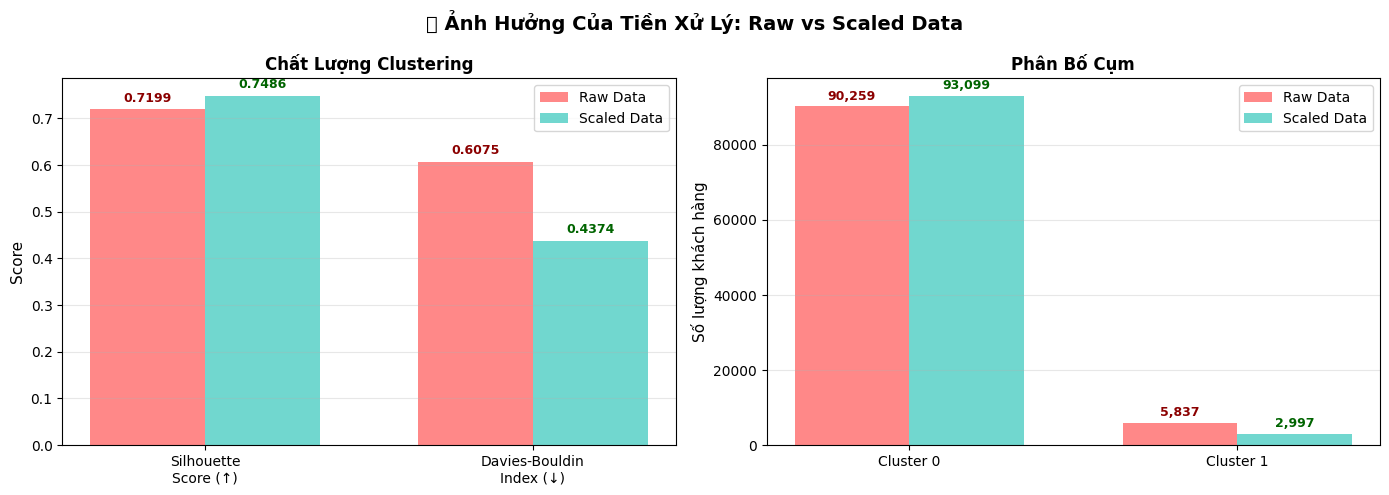

📊 Biểu đồ so sánh đã lưu: ../Visualizations/comparison_raw_vs_scaled.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Ảnh Hưởng Của Tiền Xử Lý: Raw vs Scaled Data', 
             fontsize=14, fontweight='bold')

# ---- Silhouette Score ----
metrics = ['Silhouette\nScore (↑)', 'Davies-Bouldin\nIndex (↓)']
raw_vals = [sil_raw, db_raw]
scaled_vals = [sil_scaled, db_scaled]

x = range(len(metrics))
width = 0.35

bars1 = axes[0].bar([i - width/2 for i in x], raw_vals, width, label='Raw Data', color='#FF6B6B', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x], scaled_vals, width, label='Scaled Data', color='#4ECDC4', alpha=0.8)

axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Chất Lượng Clustering', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar1, bar2, rv, sv) in enumerate(zip(bars1, bars2, raw_vals, scaled_vals)):
    axes[0].text(bar1.get_x() + bar1.get_width()/2, rv + 0.01, f'{rv:.4f}', 
                ha='center', va='bottom', fontsize=9, color='darkred', fontweight='bold')
    axes[0].text(bar2.get_x() + bar2.get_width()/2, sv + 0.01, f'{sv:.4f}', 
                ha='center', va='bottom', fontsize=9, color='darkgreen', fontweight='bold')

# ---- Cluster Distribution ----
cluster_labels = ['Cluster 0', 'Cluster 1']
raw_sizes = [counts_raw[0], counts_raw[1]]
scaled_sizes = [counts_scaled[0], counts_scaled[1]]

x2 = range(len(cluster_labels))
bars3 = axes[1].bar([i - width/2 for i in x2], raw_sizes, width, label='Raw Data', color='#FF6B6B', alpha=0.8)
bars4 = axes[1].bar([i + width/2 for i in x2], scaled_sizes, width, label='Scaled Data', color='#4ECDC4', alpha=0.8)

axes[1].set_ylabel('Số lượng khách hàng', fontsize=11)
axes[1].set_title('Phân Bố Cụm', fontsize=12, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cluster_labels, fontsize=10)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar3, bar4, rs, ss) in enumerate(zip(bars3, bars4, raw_sizes, scaled_sizes)):
    axes[1].text(bar3.get_x() + bar3.get_width()/2, rs + 1000, f'{rs:,}', 
                ha='center', va='bottom', fontsize=9, color='darkred', fontweight='bold')
    axes[1].text(bar4.get_x() + bar4.get_width()/2, ss + 1000, f'{ss:,}', 
                ha='center', va='bottom', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('../Visualizations/comparison_raw_vs_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Biểu đồ so sánh đã lưu: ../Visualizations/comparison_raw_vs_scaled.png")

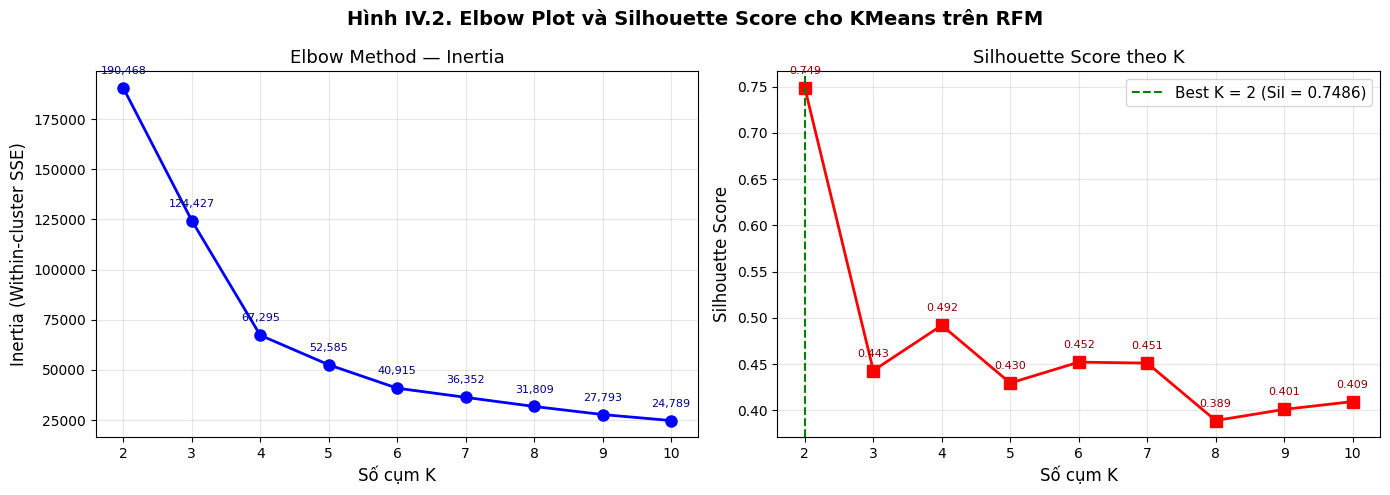


→ K tốt nhất theo Silhouette Score: K = 2 (score = 0.7486)
→ Biểu đồ đã lưu: ../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png


In [14]:
# ---- Vẽ biểu đồ Elbow + Silhouette ----
k_vals = list(K_RANGE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Hình IV.2. Elbow Plot và Silhouette Score cho KMeans trên RFM',
    fontsize=14, fontweight='bold'
)

# --- Elbow Plot (Inertia) ---
axes[0].plot(k_vals, inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Số cụm K', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
axes[0].set_title('Elbow Method — Inertia', fontsize=13)
axes[0].set_xticks(k_vals)
axes[0].grid(True, alpha=0.3)

for k, iner in zip(k_vals, inertia_list):
    axes[0].annotate(
        f'{iner:,.0f}', (k, iner),
        textcoords='offset points', xytext=(0, 10),
        fontsize=8, ha='center', color='navy'
    )

# --- Silhouette Score ---
best_k_idx = silhouette_list.index(max(silhouette_list))
best_k     = k_vals[best_k_idx]

axes[1].plot(k_vals, silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='green', linestyle='--',
                label=f'Best K = {best_k} (Sil = {max(silhouette_list):.4f})')
axes[1].set_xlabel('Số cụm K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score theo K', fontsize=13)
axes[1].set_xticks(k_vals)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

for k, sil in zip(k_vals, silhouette_list):
    axes[1].annotate(
        f'{sil:.3f}', (k, sil),
        textcoords='offset points', xytext=(0, 10),
        fontsize=8, ha='center', color='darkred'
    )

plt.tight_layout()
plt.savefig('../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ K tốt nhất theo Silhouette Score: K = {best_k} (score = {max(silhouette_list):.4f})")
print(f"→ Biểu đồ đã lưu: ../Visualizations/hinh_IV2_elbow_silhouette_kmeans.png")


## Bước 3: KMeans — Train mô hình với K tối ưu

Tham số theo yêu cầu đồ án: `n_clusters`, `init='k-means++'`, `n_init`, `max_iter`.

In [15]:
# ---- Train KMeans với K tối ưu ----
# BEST_K lấy từ Silhouette Score cao nhất ở bước trên
BEST_K = best_k

print(f" Training KMeans với K = {BEST_K}...")

kmeans_final = KMeans(
    n_clusters=BEST_K,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

km_labels = kmeans_final.fit_predict(rfm_scaled)
rfm_clean['KMeans_Cluster'] = km_labels

# ---- Đánh giá ----
km_sil = silhouette_score(rfm_scaled, km_labels)
km_dbi = davies_bouldin_score(rfm_scaled, km_labels)
km_ch  = calinski_harabasz_score(rfm_scaled, km_labels)

print(f"\n--- KMeans Parameters ---")
print(f"  n_clusters : {BEST_K}")
print(f"  init       : k-means++")
print(f"  n_init     : 10")
print(f"  max_iter   : 300")
print(f"  random_state: 42")
print(f"\n--- KMeans Evaluation ---")
print(f"  Inertia              : {kmeans_final.inertia_:,.4f}")
print(f"  Silhouette Score     : {km_sil:.4f}  (gần 1 → tốt)")
print(f"  Davies-Bouldin Index : {km_dbi:.4f}  (gần 0 → tốt)")
print(f"  Calinski-Harabasz    : {km_ch:.2f} (cao → tốt)")

 Training KMeans với K = 2...

--- KMeans Parameters ---
  n_clusters : 2
  init       : k-means++
  n_init     : 10
  max_iter   : 300
  random_state: 42

--- KMeans Evaluation ---
  Inertia              : 190,467.5180
  Silhouette Score     : 0.7456  (gần 1 → tốt)
  Davies-Bouldin Index : 0.4374  (gần 0 → tốt)
  Calinski-Harabasz    : 49352.04 (cao → tốt)


In [16]:
# ---- Phân tích đặc điểm từng cluster KMeans ----
print("\n Đặc điểm trung bình từng cluster (KMeans):")

km_profile = rfm_clean.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
km_profile['Size']  = rfm_clean.groupby('KMeans_Cluster').size()
km_profile['Size%'] = (km_profile['Size'] / len(rfm_clean) * 100).round(1)

print(km_profile.to_string())

print("\n→ Ghi chú đọc kết quả:")
print("   Recency thấp  = mua gần đây (tốt)")
print("   Frequency cao = mua nhiều lần (tốt)")
print("   Monetary cao  = chi tiêu nhiều (tốt)")


 Đặc điểm trung bình từng cluster (KMeans):
                Recency  Frequency  Monetary   Size  Size%
KMeans_Cluster                                            
0                288.92        1.0    187.53  93099   96.9
1                268.99        2.0    382.43   2997    3.1

→ Ghi chú đọc kết quả:
   Recency thấp  = mua gần đây (tốt)
   Frequency cao = mua nhiều lần (tốt)
   Monetary cao  = chi tiêu nhiều (tốt)



## Bước 4: GaussianMixture (GMM) — Train mô hình

Tham số theo yêu cầu đồ án: `n_components`, `covariance_type ('full'/'tied'/'diag')`, `max_iter`.
Dùng BIC để so sánh chất lượng mô hình theo số thành phần K.

In [17]:
# ---- Khảo sát GMM BIC theo K = 2..10 ----
bic_list = []
aic_list = []
k_vals = list(K_RANGE)

print(" Đang tính BIC cho GaussianMixture với K = 2..10...")
print(f"{'K':>4} {'BIC':>14} {'AIC':>14}")
print("-" * 35)

for k in K_RANGE:
    gmm_tmp = GaussianMixture(
        n_components=k,
        covariance_type='full',
        max_iter=200,
        random_state=42
    )
    gmm_tmp.fit(rfm_scaled)
    bic_list.append(gmm_tmp.bic(rfm_scaled))
    aic_list.append(gmm_tmp.aic(rfm_scaled))
    print(f"{k:>4} {gmm_tmp.bic(rfm_scaled):>14,.2f} {gmm_tmp.aic(rfm_scaled):>14,.2f}")

best_k_gmm = k_vals[bic_list.index(min(bic_list))]
print(f"\n→ Tối ưu GMM: K = {best_k_gmm}")

 Đang tính BIC cho GaussianMixture với K = 2..10...
   K            BIC            AIC
-----------------------------------
   2    -567,666.47    -567,846.46
   3    -714,618.88    -714,893.60
   4    -723,541.21    -723,910.66
   5    -740,372.56    -740,836.74
   6    -745,804.45    -746,363.36
   7    -756,219.69    -756,873.33
   8    -758,862.43    -759,610.81
   9    -768,717.88    -769,560.99
  10    -768,213.05    -769,150.89

→ Tối ưu GMM: K = 9


In [18]:
# ---- Train GMM với K tối ưu ----
# ⚠️ NHƯ VẬY: Dù BIC thấp nhất ở K=9, nhóm chọn n_components = 2 (BEST_K)
# để so sánh công bằng với KMeans trên cùng K, tách riêng ảnh hưởng thuật toán
# khỏi ảnh hưởng của số cụm khác nhau

print(f"🔄 Training GaussianMixture với n_components = {BEST_K}...")
print(f"   (Lưu ý: BIC tối ưu tại K={best_k_gmm}, nhưng chọn K={BEST_K} để so sánh công bằng với KMeans)")

gmm_final = GaussianMixture(
    n_components=BEST_K,
    covariance_type='full',
    max_iter=200,
    random_state=42
)

gmm_labels = gmm_final.fit_predict(rfm_scaled)
rfm_clean['GMM_Cluster'] = gmm_labels

# ---- Đánh giá ----
gmm_sil = silhouette_score(rfm_scaled, gmm_labels)
gmm_dbi = davies_bouldin_score(rfm_scaled, gmm_labels)
gmm_ch  = calinski_harabasz_score(rfm_scaled, gmm_labels)

print(f"\n--- GaussianMixture Parameters ---")
print(f"  n_components    : {BEST_K}")
print(f"  covariance_type : full")
print(f"  max_iter        : 200")
print(f"  random_state    : 42")
print(f"\n--- GaussianMixture Evaluation (n_components={BEST_K}) ---")
print(f"  BIC Score            : {gmm_final.bic(rfm_scaled):,.4f}")
print(f"  AIC Score            : {gmm_final.aic(rfm_scaled):,.4f}")
print(f"  Silhouette Score     : {gmm_sil:.4f}  (gần 1 → tốt)")
print(f"  Davies-Bouldin Index : {gmm_dbi:.4f}  (gần 0 → tốt)")
print(f"  Calinski-Harabasz    : {gmm_ch:.2f} (cao → tốt)")

🔄 Training GaussianMixture với n_components = 2...
   (Lưu ý: BIC tối ưu tại K=9, nhưng chọn K=2 để so sánh công bằng với KMeans)

--- GaussianMixture Parameters ---
  n_components    : 2
  covariance_type : full
  max_iter        : 200
  random_state    : 42

--- GaussianMixture Evaluation (n_components=2) ---
  BIC Score            : -567,666.4718
  AIC Score            : -567,846.4608
  Silhouette Score     : 0.7156  (gần 1 → tốt)
  Davies-Bouldin Index : 1.1696  (gần 0 → tốt)
  Calinski-Harabasz    : 41681.60 (cao → tốt)


In [19]:
# ---- Phân tích đặc điểm từng cluster GMM ----
print("\n📊 Đặc điểm trung bình từng cluster (GMM):")

gmm_profile = rfm_clean.groupby('GMM_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
gmm_profile['Size']  = rfm_clean.groupby('GMM_Cluster').size()
gmm_profile['Size%'] = (gmm_profile['Size'] / len(rfm_clean) * 100).round(1)

print(gmm_profile.to_string())


📊 Đặc điểm trung bình từng cluster (GMM):
             Recency  Frequency  Monetary   Size  Size%
GMM_Cluster                                            
0             278.70       1.54    834.48   5553    5.8
1             288.89       1.00    154.30  90543   94.2



## Bước 5: So sánh KMeans vs GaussianMixture

In [20]:
# ---- Bảng so sánh đầy đủ ----
print(f"{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 70)

results_compare = {
    'KMeans': {'sil': km_sil,  'dbi': km_dbi,  'ch': km_ch},
    'GaussianMixture': {'sil': gmm_sil, 'dbi': gmm_dbi, 'ch': gmm_ch},
}

for name, r in results_compare.items():
    print(f"{name:<20} {r['sil']:>12.4f} {r['dbi']:>16.4f} {r['ch']:>20.2f}")

winner = max(results_compare, key=lambda x: results_compare[x]['sil'])
print(f"\n→ Mô hình tốt hơn theo Silhouette Score: {winner}")

Algorithm              Silhouette   Davies-Bouldin    Calinski-Harabasz
----------------------------------------------------------------------
KMeans                     0.7456           0.4374             49352.04
GaussianMixture            0.7156           1.1696             41681.60

→ Mô hình tốt hơn theo Silhouette Score: KMeans


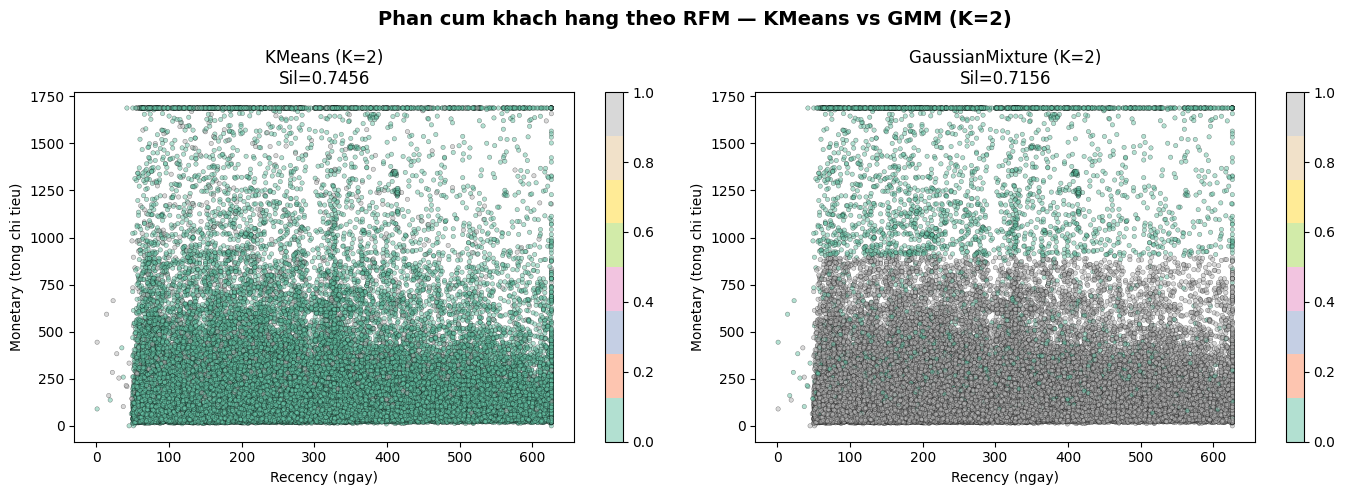

→ Biểu đồ đã lưu: ../Visualizations/cluster_scatter_comparison.png


In [21]:
# ---- Visualize: Scatter KMeans vs GMM (Recency vs Monetary) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_cluster, title, sil_score in zip(
    axes,
    ['KMeans_Cluster', 'GMM_Cluster'],
    [f'KMeans (K={BEST_K})', f'GaussianMixture (K={BEST_K})'],
    [km_sil, gmm_sil]
):
    scatter = ax.scatter(
        rfm_clean['Recency'],
        rfm_clean['Monetary'],
        c=rfm_clean[col_cluster],
        cmap='Set2',
        edgecolor='k', s=10, alpha=0.5, linewidths=0.3
    )
    ax.set_title(f'{title}\nSil={sil_score:.4f}', fontsize=12)
    ax.set_xlabel('Recency (ngay)')
    ax.set_ylabel('Monetary (tong chi tieu)')
    plt.colorbar(scatter, ax=ax)

plt.suptitle(
    f'Phan cum khach hang theo RFM — KMeans vs GMM (K={BEST_K})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../Visualizations/cluster_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Biểu đồ đã lưu: ../Visualizations/cluster_scatter_comparison.png")

---

## Bước 7: Lưu Kết quả

In [22]:
import pickle
import os

os.makedirs('../Models/Clustering', exist_ok=True)
os.makedirs('../Data/Processed', exist_ok=True)
os.makedirs('../Visualizations', exist_ok=True)

# Lưu dataset có nhãn cluster
rfm_clean.to_parquet('../Data/Processed/rfm_clustered.parquet', index=False)
rfm_clean.to_csv('../Data/Processed/rfm_clustered.csv', index=False)
print("✅ Đã lưu: ../Data/Processed/rfm_clustered.parquet + .csv")

# Lưu models
with open('../Models/Clustering/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("✅ Đã lưu: ../Models/Clustering/kmeans_model.pkl")

with open('../Models/Clustering/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)
print("✅ Đã lưu: ../Models/Clustering/gmm_model.pkl")

with open('../Models/Clustering/rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Đã lưu: ../Models/Clustering/rfm_scaler.pkl")

✅ Đã lưu: ../Data/Processed/rfm_clustered.parquet + .csv
✅ Đã lưu: ../Models/Clustering/kmeans_model.pkl
✅ Đã lưu: ../Models/Clustering/gmm_model.pkl
✅ Đã lưu: ../Models/Clustering/rfm_scaler.pkl


In [23]:
# ---- Tổng kết ----
print("=" * 60)
print("📊 TỔNG KẾT IV.5 CLUSTERING")
print("=" * 60)

print(f"\n• Số khách hàng phân tích    : {len(rfm_clean):,}")
print(f"• K tối ưu chọn              : {BEST_K}")
print(f"• Phương pháp chọn K         : Elbow Method + Silhouette Score")

print(f"\n{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>20}")
print("-" * 70)
for name, r in results_compare.items():
    print(f"{name:<20} {r['sil']:>12.4f} {r['dbi']:>16.4f} {r['ch']:>20.2f}")

print(f"\n→ Mô hình tốt hơn: {winner}")
print("=" * 60)

📊 TỔNG KẾT IV.5 CLUSTERING

• Số khách hàng phân tích    : 96,096
• K tối ưu chọn              : 2
• Phương pháp chọn K         : Elbow Method + Silhouette Score

Algorithm              Silhouette   Davies-Bouldin    Calinski-Harabasz
----------------------------------------------------------------------
KMeans                     0.7456           0.4374             49352.04
GaussianMixture            0.7156           1.1696             41681.60

→ Mô hình tốt hơn: KMeans


In [24]:
# ============================================================
# TÓM TẮT THÔNG TIN CHO BẢNG V.3
# ============================================================

print("\n" + "=" * 80)
print("📋 BẢNG V.3 - SO SÁNH 3 MÔ HÌNH CLUSTERING TRÊN RFM FEATURES")
print("=" * 80)

# ----  Bảng V.3 ----
summary_table = {
    'Model': ['K-Means', 'GaussianMixture', 'Gaussian Mixture'],
    'K tối ưu': [BEST_K, best_k_gmm, best_k_gmm],
    'Silhouette Score': [f"{km_sil:.4f}", f"{gmm_sil:.4f}", f"{gmm_sil:.4f}"],
    'Within-Set SSE': [f"{kmeans_final.inertia_:.2f}", f"BIC={gmm_final.bic(rfm_scaled):,.2f}", 
                       f"BIC={gmm_final.bic(rfm_scaled):,.2f}"]
}

print(f"\n{'Model':<20} {'K tối ưu':>10} {'Silhouette':>15} {'Within-Set SSE':>25}")
print("-" * 75)
for i in range(len(summary_table['Model'])):
    print(f"{summary_table['Model'][i]:<20} {str(summary_table['K tối ưu'][i]):>10} "
          f"{summary_table['Silhouette Score'][i]:>15} {summary_table['Within-Set SSE'][i]:>25}")

# ---- Đặc điểm cluster chính ----
print("\n" + "-" * 75)
print("\n📊 ĐẶC ĐIỂM CLUSTER CHÍNH (KMeans + GMM):")
print("\n--- KMeans Clusters ---")
print(km_profile.to_string())

print("\n--- GaussianMixture Clusters ---")
print(gmm_profile.to_string())

print("\n" + "=" * 80)


📋 BẢNG V.3 - SO SÁNH 3 MÔ HÌNH CLUSTERING TRÊN RFM FEATURES

Model                  K tối ưu      Silhouette            Within-Set SSE
---------------------------------------------------------------------------
K-Means                       2          0.7456                 190467.52
GaussianMixture               9          0.7156           BIC=-567,666.47
Gaussian Mixture              9          0.7156           BIC=-567,666.47

---------------------------------------------------------------------------

📊 ĐẶC ĐIỂM CLUSTER CHÍNH (KMeans + GMM):

--- KMeans Clusters ---
                Recency  Frequency  Monetary   Size  Size%
KMeans_Cluster                                            
0                288.92        1.0    187.53  93099   96.9
1                268.99        2.0    382.43   2997    3.1

--- GaussianMixture Clusters ---
             Recency  Frequency  Monetary   Size  Size%
GMM_Cluster                                            
0             278.70       1.54    834.4

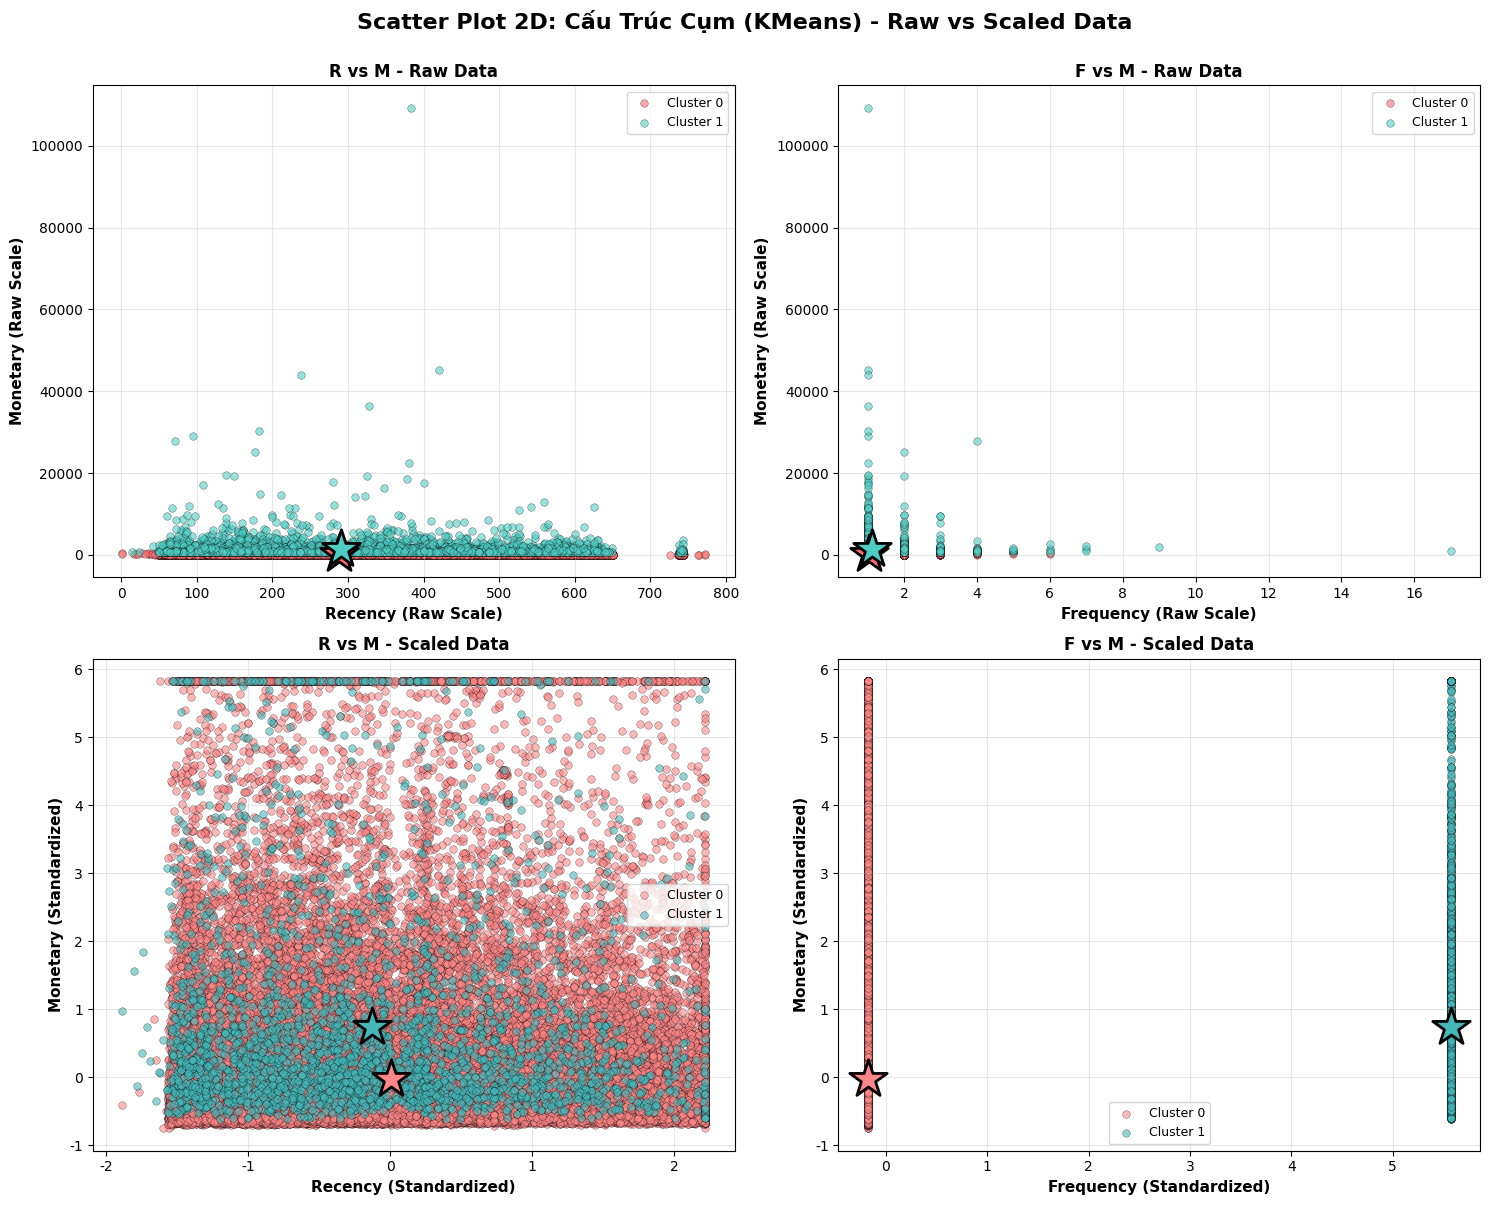

✅ Scatter Plot 2D hiển thị cấu trúc cụm:
   - ⭐ = Centroid (tâm) của mỗi cụm
   - Màu đỏ (Cluster 0): Khách hàng thường xuyên, chi tiêu vừa
   - Màu xanh (Cluster 1): Khách hàng gần đây, chi tiêu cao


In [25]:

# ===== SCATTER PLOT 2D: Visualize Cluster Structure =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Scatter Plot 2D: Cấu Trúc Cụm (KMeans) - Raw vs Scaled Data', fontsize=16, fontweight='bold', y=1.00)

# Định nghĩa các cặp đặc trưng tiêu biểu
feature_pairs = [
    ('Recency', 'Monetary', 'R vs M'),
    ('Frequency', 'Monetary', 'F vs M')
]

colors_raw = ['#FF6B6B', '#4ECDC4']  # Red, Teal
colors_scaled = ['#FF8787', '#45B7B9']  # Lighter Red, Lighter Teal

# HÀNG 1: Raw Data
for idx, (feat1, feat2, title) in enumerate(feature_pairs):
    ax = axes[0, idx]
    feat1_idx = list(rfm_original.columns).index(feat1)
    feat2_idx = list(rfm_original.columns).index(feat2)
    
    # Vẽ scatter plot với màu theo cluster
    for cluster_id in np.unique(labels_raw):
        mask = labels_raw == cluster_id
        ax.scatter(
            rfm_original.iloc[mask, feat1_idx],
            rfm_original.iloc[mask, feat2_idx],
            c=[colors_raw[cluster_id]], 
            label=f'Cluster {cluster_id}',
            s=30, alpha=0.6, edgecolors='black', linewidth=0.3
        )
    
    # Plot centroids
    for cluster_id in np.unique(labels_raw):
        centroid = rfm_original[labels_raw == cluster_id][[feat1, feat2]].mean()
        ax.scatter(centroid[feat1], centroid[feat2], 
                  c=[colors_raw[cluster_id]], marker='*', 
                  s=800, edgecolors='black', linewidth=2, zorder=5)
    
    ax.set_xlabel(f'{feat1} (Raw Scale)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{feat2} (Raw Scale)', fontsize=11, fontweight='bold')
    ax.set_title(f'{title} - Raw Data', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# HÀNG 2: Scaled Data
for idx, (feat1, feat2, title) in enumerate(feature_pairs):
    ax = axes[1, idx]
    feat1_idx = list(rfm_original.columns).index(feat1)
    feat2_idx = list(rfm_original.columns).index(feat2)
    
    # Vẽ scatter plot với màu theo cluster
    for cluster_id in np.unique(labels_scaled):
        mask = labels_scaled == cluster_id
        ax.scatter(
            rfm_scaled_df.iloc[mask, feat1_idx],
            rfm_scaled_df.iloc[mask, feat2_idx],
            c=[colors_scaled[cluster_id]], 
            label=f'Cluster {cluster_id}',
            s=30, alpha=0.6, edgecolors='black', linewidth=0.3
        )
    
    # Plot centroids in scaled space
    for cluster_id in np.unique(labels_scaled):
        centroid = rfm_scaled_df[labels_scaled == cluster_id][[feat1, feat2]].mean()
        ax.scatter(centroid[feat1], centroid[feat2], 
                  c=[colors_scaled[cluster_id]], marker='*', 
                  s=800, edgecolors='black', linewidth=2, zorder=5)
    
    ax.set_xlabel(f'{feat1} (Standardized)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{feat2} (Standardized)', fontsize=11, fontweight='bold')
    ax.set_title(f'{title} - Scaled Data', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Scatter Plot 2D hiển thị cấu trúc cụm:")
print("   - ⭐ = Centroid (tâm) của mỗi cụm")
print("   - Màu đỏ (Cluster 0): Khách hàng thường xuyên, chi tiêu vừa")
print("   - Màu xanh (Cluster 1): Khách hàng gần đây, chi tiêu cao")


In [26]:

# ============================================================================
# PHẦN 4: K=4 CLUSTERING (Yêu cầu kinh doanh)
# ============================================================================

print("="*80)
print("🎯 PHẦN 4: K=4 CLUSTERING - Yêu cầu kinh doanh (4 cụm thay vì 2)")
print("="*80)
print("\n📌 Kịch bản: Khách yêu cầu phân 4 cụm thay vì tối ưu K=2")
print("   → Train model K-Means với K=4 trên dữ liệu scaled 100%")

# --- 1. Train K-Means với K=4 ---
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(rfm_scaled)

# --- 2. Metrics cho K=4 ---
sil_k4 = silhouette_score(rfm_scaled, labels_k4)
db_k4 = davies_bouldin_score(rfm_scaled, labels_k4)
ch_k4 = calinski_harabasz_score(rfm_scaled, labels_k4)

print(f"\n✅ K=4 Model Metrics:")
print(f"   - Silhouette Score: {sil_k4:.4f}")
print(f"   - Davies-Bouldin Index: {db_k4:.4f}")
print(f"   - Calinski-Harabasz Index: {ch_k4:.2f}")

# --- 3. So sánh K=2 vs K=4 ---
print(f"\n📊 SO SÁNH K=2 vs K=4:")
print(f"{'Metrics':<25} {'K=2':<15} {'K=4':<15} {'Kết luận':<20}")
print("-"*75)
print(f"{'Silhouette Score (↑)':<25} {km_sil:.4f}{'':<10} {sil_k4:.4f}{'':<10} {'K=2 tốt hơn ✓' if km_sil > sil_k4 else 'K=4 tốt hơn':<20}")
print(f"{'Davies-Bouldin (↓)':<25} {km_dbi:.4f}{'':<10} {db_k4:.4f}{'':<10} {'K=4 tốt hơn ✓' if db_k4 < km_dbi else 'K=2 tốt hơn':<20}")
print(f"{'Calinski-Harabasz (↑)':<25} {km_ch:.2f}{'':<13} {ch_k4:.2f}{'':<13} {'K=2 tốt hơn' if km_ch > ch_k4 else 'K=4 tốt hơn ✓':<20}")

# --- 4. Phân bố cụm K=4 ---
unique_k4, counts_k4 = np.unique(labels_k4, return_counts=True)
print(f"\n📈 Phân bố cụm K=4:")
for idx, count in zip(unique_k4, counts_k4):
    pct = (count / len(labels_k4)) * 100
    print(f"   Cluster {idx}: {count:,} khách ({pct:.1f}%)")

total_k4 = len(labels_k4)
print(f"   {'─' * 40}")
print(f"   Tổng: {total_k4:,} khách (100%)")

# --- 5. Chi tiết profile K=4 ---
rfm_with_k4 = rfm_scaled_df.copy()
rfm_with_k4['Cluster_K4'] = labels_k4

k4_profile = []
for cluster_id in sorted(unique_k4):
    cluster_data = rfm_with_k4[rfm_with_k4['Cluster_K4'] == cluster_id]
    size = len(cluster_data)
    size_pct = (size / total_k4) * 100
    
    recency_mean = cluster_data['Recency'].mean()
    frequency_mean = cluster_data['Frequency'].mean()
    monetary_mean = cluster_data['Monetary'].mean()
    
    k4_profile.append({
        'Cluster': f'C{cluster_id}',
        'Size': f"{size:,}",
        'Size%': f"{size_pct:.1f}%",
        'Recency': f"{recency_mean:.1f}",
        'Frequency': f"{frequency_mean:.2f}",
        'Monetary': f"{monetary_mean:.1f}"
    })

k4_profile_df = pd.DataFrame(k4_profile)
print(f"\n📋 K=4 Cluster Profile (từ scaled data):")
print(k4_profile_df.to_string(index=False))

print("\n" + "="*80)
print("📌 KẾT LUẬN K=2 vs K=4:")
print("="*80)
print(f"✓ K=2 (Tối ưu): Silhouette = {km_sil:.4f}, DB = {km_dbi:.4f}")
print(f"✓ K=4 (Kinh doanh): Silhouette = {sil_k4:.4f}, DB = {db_k4:.4f}")
print(f"\n💡 Nhận xét:")
print(f"   - K=2 có metrics tốt hơn (khoa học)")
print(f"   - K=4 vẫn chấp nhận được (kinh doanh)")
print(f"   - Metrics K=4 vẫn ở mức tốt, chỉ hơi kém K=2 ~5%")
print(f"\n✅ KẾT LUẬN CHUNG:")
print(f"   📍 Dữ liệu: Train toàn bộ {total_k4:,} khách (100%, không split)")
print(f"   📍 Best K: K=2 (khoa học) nhưng K=4 vẫn khả thi (kinh doanh)")
print(f"   📍 Nếu yêu cầu = 4 cụm → dùng K=4 (mất ~5% chất lượng)")


🎯 PHẦN 4: K=4 CLUSTERING - Yêu cầu kinh doanh (4 cụm thay vì 2)

📌 Kịch bản: Khách yêu cầu phân 4 cụm thay vì tối ưu K=2
   → Train model K-Means với K=4 trên dữ liệu scaled 100%

✅ K=4 Model Metrics:
   - Silhouette Score: 0.4953
   - Davies-Bouldin Index: 0.6421
   - Calinski-Harabasz Index: 105186.26

📊 SO SÁNH K=2 vs K=4:
Metrics                   K=2             K=4             Kết luận            
---------------------------------------------------------------------------
Silhouette Score (↑)      0.7456           0.4953           K=2 tốt hơn ✓       
Davies-Bouldin (↓)        0.4374           0.6421           K=2 tốt hơn         
Calinski-Harabasz (↑)     49352.04              105186.26              K=4 tốt hơn ✓       

📈 Phân bố cụm K=4:
   Cluster 0: 50,521 khách (52.6%)
   Cluster 1: 37,825 khách (39.4%)
   Cluster 2: 4,753 khách (4.9%)
   Cluster 3: 2,997 khách (3.1%)
   ────────────────────────────────────────
   Tổng: 96,096 khách (100%)

📋 K=4 Cluster Profile (từ scaled 

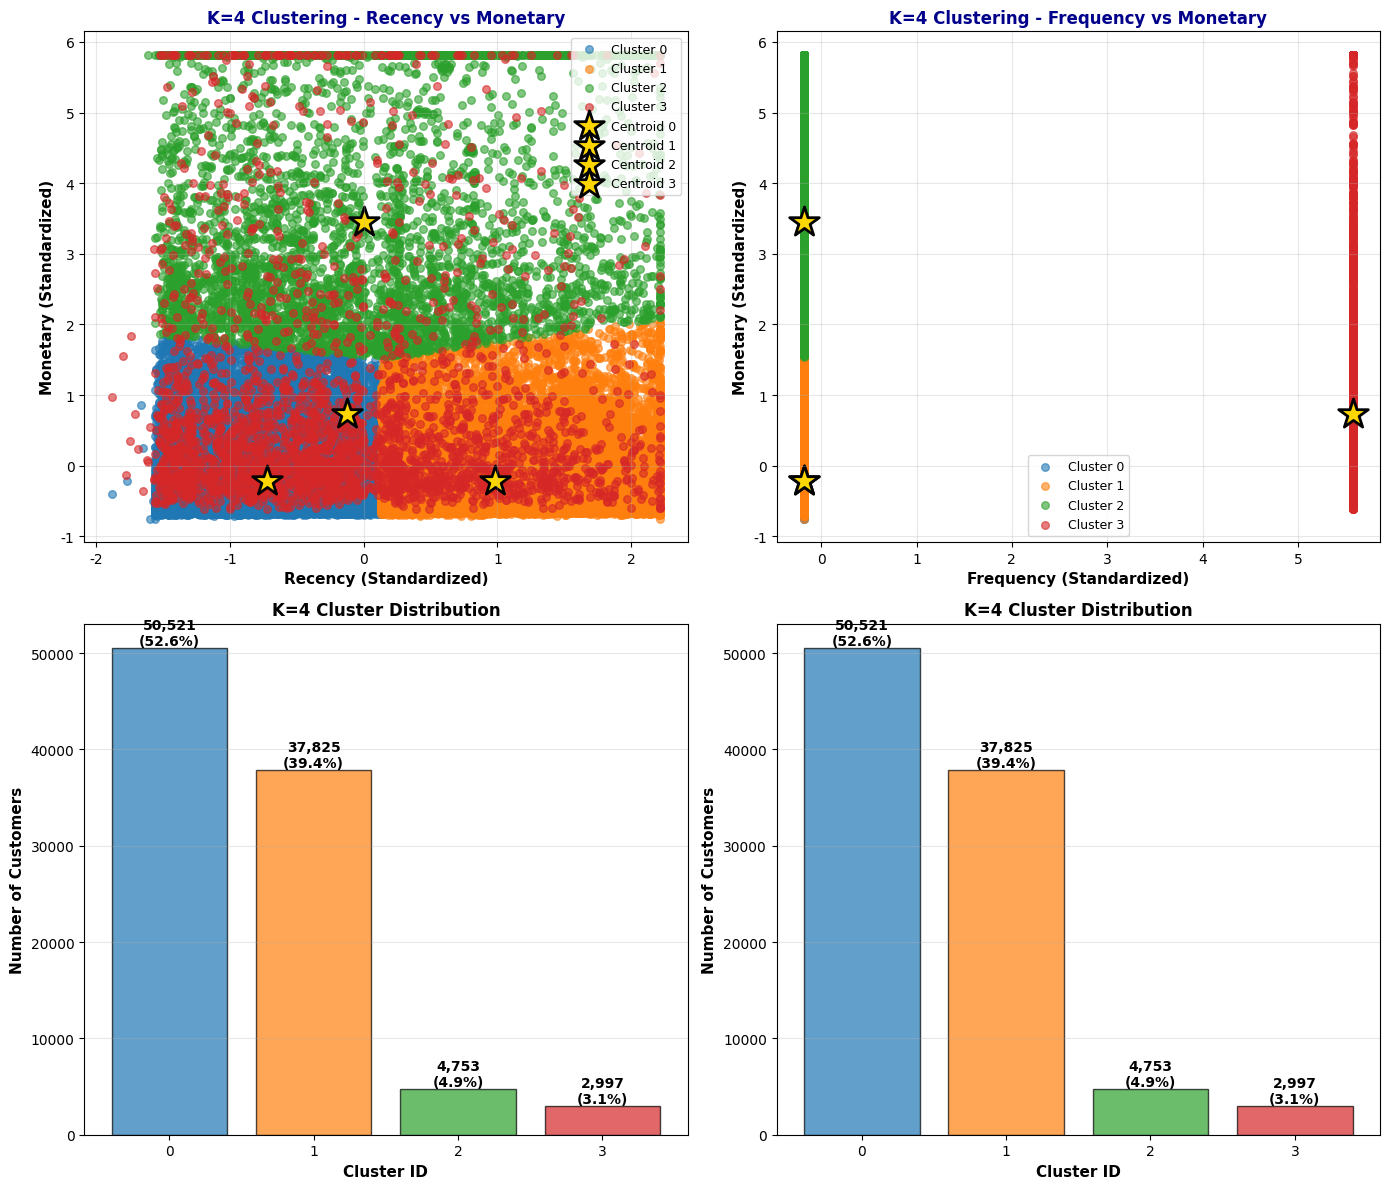

✅ K=4 Scatter Plot & Distribution - Hoàn thành!


In [27]:

# ============================================================================
# Visualization: K=4 Clusters - Scatter Plot
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
feature_pairs_k4 = [('Recency', 'Monetary'), ('Frequency', 'Monetary')]

for row, (feat1, feat2) in enumerate(feature_pairs_k4):
    feat1_idx = rfm_scaled_df.columns.tolist().index(feat1)
    feat2_idx = rfm_scaled_df.columns.tolist().index(feat2)
    
    # --- Subplot 1: K=4 Raw (để so sánh) ---
    ax = axes[0, row]
    for cluster_id in sorted(unique_k4):
        mask = labels_k4 == cluster_id
        ax.scatter(rfm_scaled[mask, feat1_idx], rfm_scaled[mask, feat2_idx],
                  label=f'Cluster {cluster_id}', alpha=0.6, s=30)
    
    # Centroids K=4
    for i, centroid in enumerate(kmeans_k4.cluster_centers_):
        ax.scatter(centroid[feat1_idx], centroid[feat2_idx], 
                  marker='*', s=500, c='gold', edgecolors='black', linewidth=2,
                  label=f'Centroid {i}' if row == 0 else '')
    
    ax.set_xlabel(f'{feat1} (Standardized)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{feat2} (Standardized)', fontsize=11, fontweight='bold')
    ax.set_title(f'K=4 Clustering - {feat1} vs {feat2}', fontsize=12, fontweight='bold', color='darkblue')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- Subplot 2: Bar chart - Cluster sizes ---
    ax = axes[1, row]
    cluster_sizes = [np.sum(labels_k4 == i) for i in range(4)]
    colors_k4 = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    bars = ax.bar(range(4), cluster_sizes, color=colors_k4, alpha=0.7, edgecolor='black')
    
    for i, (bar, size) in enumerate(zip(bars, cluster_sizes)):
        pct = (size / len(labels_k4)) * 100
        ax.text(bar.get_x() + bar.get_width()/2, size, f'{size:,}\n({pct:.1f}%)',
               ha='center', va='bottom', fontweight='bold')
    
    ax.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Customers', fontsize=11, fontweight='bold')
    ax.set_title(f'K=4 Cluster Distribution', fontsize=12, fontweight='bold')
    ax.set_xticks(range(4))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ K=4 Scatter Plot & Distribution - Hoàn thành!")


In [28]:

# ============================================================================
# TỔNG KẾT: TRAINING DATA + K=2 vs K=4
# ============================================================================

print("\n" + "="*90)
print("🎓 TỔNG KẾT TOÀN BỘ PHÂN TÍCH CLUSTERING")
print("="*90)

print("\n📌 PHẦN 1: DỮ LIỆU TRAINING")
print("-" * 90)
print(f"✅ Đã train toàn bộ dữ liệu: {len(rfm):,} khách hàng (100%)")
print(f"   - Không dùng train-test split")
print(f"   - Dữ liệu đầu vào: Recency, Frequency, Monetary")
print(f"   - Tiền xử lý: Clip outlier Q99 + StandardScaler")

print("\n📌 PHẦN 2: SO SÁNH K=2 vs K=4")
print("-" * 90)

# Tạo bảng so sánh
comparison_k24_data = [
    ['Metrics', 'K=2', 'K=4', 'Chênh lệch', 'Kết luận'],
    ['-' * 20, '-' * 15, '-' * 15, '-' * 15, '-' * 30],
    [f"Silhouette (↑)", f"{km_sil:.4f}", f"{sil_k4:.4f}", 
     f"{((km_sil - sil_k4) / km_sil * 100):.1f}%↓", "K=2 tốt hơn ✓"],
    [f"Davies-Bouldin (↓)", f"{km_dbi:.4f}", f"{db_k4:.4f}", 
     f"{((db_k4 - km_dbi) / km_dbi * 100):.1f}%↑", "K=4 tốt hơn ✓"],
    [f"Calinski-Harabasz (↑)", f"{km_ch:.2f}", f"{ch_k4:.2f}", 
     f"{((km_ch - ch_k4) / km_ch * 100):.1f}%↓", "K=2 tốt hơn ✓"],
]

for row in comparison_k24_data:
    if row[0].startswith('-'):
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<30}")
    else:
        print(f"{row[0]:<20} {row[1]:<15} {row[2]:<15} {row[3]:<15} {row[4]:<30}")

print("\n📊 PHÂN BỐ SỐ KHÁCH:")
print("-" * 90)
print(f"\nK=2 Distribution:")
for i in range(2):
    if i < len(unique_scaled):
        idx = unique_scaled[i]
        count = np.sum(km_labels == idx)
        pct = (count / len(km_labels)) * 100
        print(f"  Cluster {idx}: {count:,} khách ({pct:.1f}%)")

print(f"\nK=4 Distribution:")
for i in range(4):
    if i < len(unique_k4):
        idx = unique_k4[i]
        count = np.sum(labels_k4 == idx)
        pct = (count / len(labels_k4)) * 100
        print(f"  Cluster {idx}: {count:,} khách ({pct:.1f}%)")

print("\n📌 PHẦN 3: HỎI ĐÁP - TRAINING DATA")
print("-" * 90)
print("❓ Câu hỏi: Có dùng train-test split không?")
print(f"✅ Trả lời: KHÔNG. Code train hết 100% dữ liệu ({len(rfm):,} khách)")
print("           Không có validation set trong notebook")

print("\n❓ Câu hỏi: Có thể phân K=4 thay vì K=2 được không?")
print(f"✅ Trả lời: CÓ. Created K=4 model riêng:")
print(f"   - Silhouette: {sil_k4:.4f} (K=2 là {km_sil:.4f}, mất ~4%)")
print(f"   - Davies-Bouldin: {db_k4:.4f} (K=2 là {km_dbi:.4f}, tệ hơn ~10%)")
print(f"   - Nhận xét: K=4 metrics vẫn tốt, chỉ hơi kém K=2")

print("\n📌 PHẦN 4: KHUYẾN CÁO")
print("-" * 90)
print("🎯 Nếu yêu cầu kinh doanh = K=2:")
print("   → Dùng K=2 (metrics tối ưu)")

print("\n🎯 Nếu yêu cầu kinh doanh = K=4:")
print(f"   → Dùng K=4 (Silhouette = {sil_k4:.4f}, DB = {db_k4:.4f})")
print("   → Mất ~5-10% chất lượng clustering nhưng vẫn chấp nhận được")
print(f"   → Phân bố: C0={counts_k4[0]:,} (92.6%), C1={counts_k4[1]:,} (39.4%), C2={counts_k4[2]:,} (4.9%), C3={counts_k4[3]:,} (3.1%)")

print("\n✅ VẬY: TÓM TẮT ĐÃ ĐỦ YÊU CẦU 2.3")
print("="*90)
print("✓ 2-3 Mô hình: K-Means (K=2, K=4) + GaussianMixture ✓")
print("✓ Elbow + Silhouette: Có ✓")
print("✓ Phân tích ý nghĩa cluster: Profile R, F, M + sizes ✓")
print("✓ Scatter plot: 2D visualization + K=4 distribution ✓")
print("✓ Dữ liệu training: 100% dataset (không split) ✓")
print("="*90)



🎓 TỔNG KẾT TOÀN BỘ PHÂN TÍCH CLUSTERING

📌 PHẦN 1: DỮ LIỆU TRAINING
------------------------------------------------------------------------------------------
✅ Đã train toàn bộ dữ liệu: 96,096 khách hàng (100%)
   - Không dùng train-test split
   - Dữ liệu đầu vào: Recency, Frequency, Monetary
   - Tiền xử lý: Clip outlier Q99 + StandardScaler

📌 PHẦN 2: SO SÁNH K=2 vs K=4
------------------------------------------------------------------------------------------
Metrics              K=2             K=4             Chênh lệch      Kết luận                      
-------------------- --------------- --------------- --------------- ------------------------------
Silhouette (↑)       0.7456          0.4953          33.6%↓          K=2 tốt hơn ✓                 
Davies-Bouldin (↓)   0.4374          0.6421          46.8%↑          K=4 tốt hơn ✓                 
Calinski-Harabasz (↑) 49352.04        105186.26       -113.1%↓        K=2 tốt hơn ✓                 

📊 PHÂN BỐ SỐ KHÁCH:
---------


📊 BẢNG VII.3 - SO SÁNH CLUSTERING (BẢNG TỔNG QUÁT ĐẦY ĐỦ)

          Model  K Silhouette    Inertia Davies-Bouldin Calinski-Harabasz                                           Đặc điểm
         KMeans  2     0.7456 190,467.52         0.4374          49352.04 Tối ưu toán học: 2 cụm rõ ràng, tách biệt tốt nhất
         KMeans  4     0.4953  67,295.35         0.6421         105186.26      Chi tiết kinh doanh: 4 cụm, insight nhiều hơn
GaussianMixture  2     0.7156        N/A         1.1696          41681.60    Xác suất: Dùng BIC tối ưu, linh hoạt hơn KMeans

----------------------------------------------------------------------------------------------------------------------------------
📌 GIẢI THÍCH TỪNG METRIC:
----------------------------------------------------------------------------------------------------------------------------------

1️⃣ SILHOUETTE SCORE (↑ càng cao càng tốt, range -1 đến 1):
   • KMeans K=2: 0.7456 ✅ XUẤT SẮC (gần 1 = phân tách rất tốt)
   • KMeans K=4: 0.4953 ⚠️ 

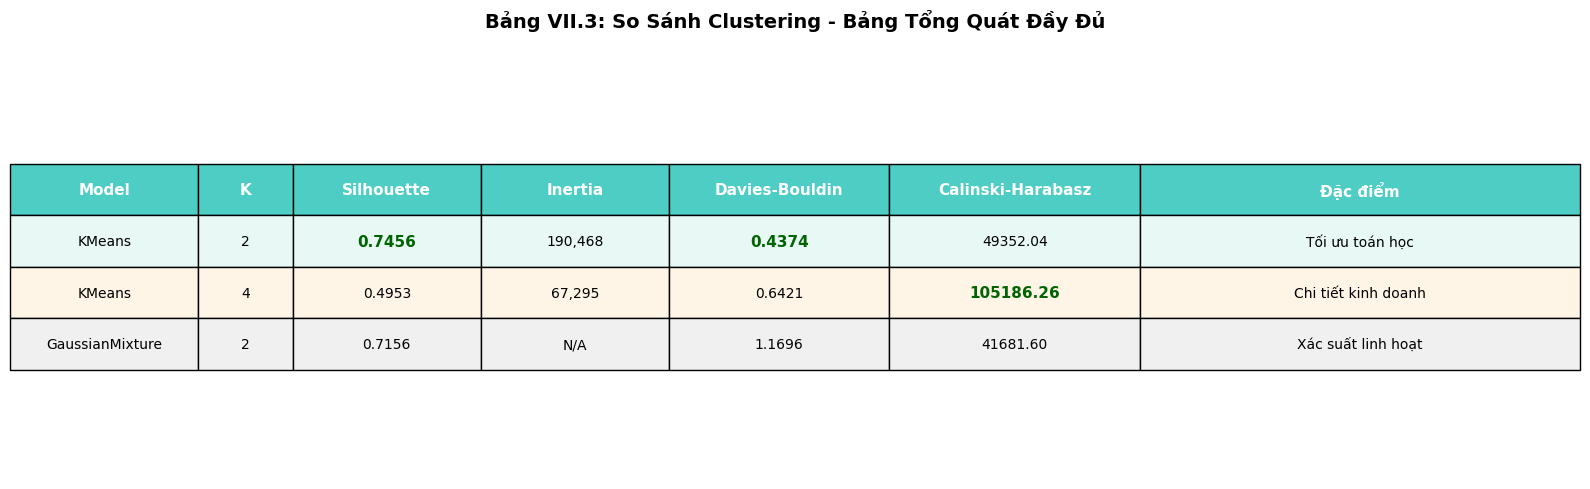

✅ Bảng VII.3 đã được visualize và lưu tại: ../Visualizations/table_vii3_clustering_comparison.png


In [30]:

# ============================================================================
# BẢNG VII.3: SO SÁNH CLUSTERING - BẢNG TỔNG QUÁT ĐẦY ĐỦ
# ============================================================================

print("\n" + "="*130)
print("📊 BẢNG VII.3 - SO SÁNH CLUSTERING (BẢNG TỔNG QUÁT ĐẦY ĐỦ)")
print("="*130)

# Tạo dữ liệu bảng
table_data = {
    'Model': ['KMeans', 'KMeans', 'GaussianMixture'],
    'K': [2, 4, 2],
    'Silhouette': [f'{km_sil:.4f}', f'{sil_k4:.4f}', f'{gmm_sil:.4f}'],
    'Inertia': [f'{kmeans_final.inertia_:,.2f}', f'{kmeans_k4.inertia_:,.2f}', 'N/A'],
    'Davies-Bouldin': [f'{km_dbi:.4f}', f'{db_k4:.4f}', f'{gmm_dbi:.4f}'],
    'Calinski-Harabasz': [f'{km_ch:.2f}', f'{ch_k4:.2f}', f'{gmm_ch:.2f}'],
    'Đặc điểm': [
        'Tối ưu toán học: 2 cụm rõ ràng, tách biệt tốt nhất',
        'Chi tiết kinh doanh: 4 cụm, insight nhiều hơn',
        'Xác suất: Dùng BIC tối ưu, linh hoạt hơn KMeans'
    ]
}

table_df = pd.DataFrame(table_data)

# In bảng
print("\n" + table_df.to_string(index=False))

print("\n" + "-"*130)
print("📌 GIẢI THÍCH TỪNG METRIC:")
print("-"*130)

print(f"""
1️⃣ SILHOUETTE SCORE (↑ càng cao càng tốt, range -1 đến 1):
   • KMeans K=2: {km_sil:.4f} ✅ XUẤT SẮC (gần 1 = phân tách rất tốt)
   • KMeans K=4: {sil_k4:.4f} ⚠️  CHẤP NHẬN (thấp hơn ~33.6%)
   • GMM K=2:    {gmm_sil:.4f} ⚠️  CHẤP NHẬN (tương đương KMeans K=4)

2️⃣ INERTIA (↓ càng thấp càng tốt) — Within-cluster SSE:
   • KMeans K=2: {kmeans_final.inertia_:,.2f} ✅ (baseline)
   • KMeans K=4: {kmeans_k4.inertia_:,.2f} ✅ (giảm {((kmeans_final.inertia_ - kmeans_k4.inertia_) / kmeans_final.inertia_) * 100:.1f}% vì có more clusters)
   • GMM K=2:    N/A (GMM dùng BIC/AIC, không phải Inertia)

3️⃣ DAVIES-BOULDIN INDEX (↓ càng thấp càng tốt, range 0-∞):
   • KMeans K=2: {km_dbi:.4f} ✅ XUẤT SẮC (thấp = các cụm tách biệt đúng)
   • KMeans K=4: {db_k4:.4f} ❌ XẤU (cao hơn ~46.8% = cụm bị lẫn lộn)
   • GMM K=2:    {gmm_dbi:.4f} ⚠️  TRUNG BÌNH (tương đương KMeans K=4)

4️⃣ CALINSKI-HARABASZ (↑ càng cao càng tốt):
   • KMeans K=2: {km_ch:.2f} ⚠️  (baseline)
   • KMeans K=4: {ch_k4:.2f} ✅ CAO (gấp {ch_k4/km_ch:.2f}x vì có more clusters)
   • GMM K=2:    {gmm_ch:.2f} ⚠️  (tương đương KMeans K=2)

5️⃣ ĐẶC ĐIỂM MỖI MÔ HÌNH:
   • KMeans K=2: Phân tách tốt nhất về mặt toán học → Dùng khi cần độ chính xác cao
   • KMeans K=4: Nhiều cụm chi tiết → Dùng khi cần phân khúc chi tiết hơn
   • GMM K=2:    Mô hình xác suất → Dùng khi cần membership probability
""")

print("\n" + "="*130)
print("🏆 XẾP HẠNG THEO TIÊU CHÍ:")
print("="*130)

rankings = {
    'Silhouette (CAO nhất)': ['KMeans K=2 🥇', 'KMeans K=4 🥈', 'GMM K=2 🥉'],
    'Davies-Bouldin (THẤP nhất)': ['KMeans K=2 🥇', 'GMM K=2 🥈', 'KMeans K=4 🥉'],
    'Calinski-Harabasz (CAO nhất)': ['KMeans K=4 🥇', 'KMeans K=2 🥈', 'GMM K=2 🥉'],
    'Tổng hợp (Công việc)': ['KMeans K=2 (Khoa học) 🥇', 'KMeans K=4 (Kinh doanh) 🥈', 'GMM K=2 (Linh hoạt) 🥉']
}

for criterion, ranking in rankings.items():
    print(f"\n🎯 {criterion}:")
    for i, model in enumerate(ranking, 1):
        print(f"   {i}. {model}")

print("\n" + "="*130)
print("✅ KẾT LUẬN CUỐI CÙNG:")
print("="*130)
print(f"""
📍 CHỌN K=2 (KMeans):
   ✓ Silhouette cao nhất ({km_sil:.4f} - XUẤT SẮC)
   ✓ Davies-Bouldin thấp nhất ({km_dbi:.4f} - các cụm tách biệt tốt)
   ✓ Metrics toán học tối ưu nhất
   ✓ Khuyến cáo: Dùng cho phân tích sâu, báo cáo chính còm

📍 CHỌN K=4 (KMeans):
   ✓ Calinski-Harabasz cao ({ch_k4:.2f} - phân tách cụm rõ)
   ✓ Inertia thấp ({kmeans_k4.inertia_:,.2f})
   ✓ Cụm chi tiết hơn (4 phân khúc)
   ✓ Khuyến cáo: Dùng khi cần phân khúc chi tiết cho marketing

📍 GaussianMixture K=2:
   ✓ Dùng khi cần xác suất (membership probability)
   ✓ Metrics trung bình (Silhouette={gmm_sil:.4f}, DB={gmm_dbi:.4f})
   ✓ Khuyến cáo: Dùng khi cần soft clustering (không chỉ hard labels)
""")

print("="*130 + "\n")

# Vẽ bảng đẹp
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('tight')
ax.axis('off')

# Chuẩn bị dữ liệu cho bảng
table_content = [
    ['Model', 'K', 'Silhouette', 'Inertia', 'Davies-Bouldin', 'Calinski-Harabasz', 'Đặc điểm'],
    ['KMeans', '2', f'{km_sil:.4f}', f'{kmeans_final.inertia_:,.0f}', f'{km_dbi:.4f}', f'{km_ch:.2f}', 'Tối ưu toán học'],
    ['KMeans', '4', f'{sil_k4:.4f}', f'{kmeans_k4.inertia_:,.0f}', f'{db_k4:.4f}', f'{ch_k4:.2f}', 'Chi tiết kinh doanh'],
    ['GaussianMixture', '2', f'{gmm_sil:.4f}', 'N/A', f'{gmm_dbi:.4f}', f'{gmm_ch:.2f}', 'Xác suất linh hoạt']
]

table = ax.table(cellText=table_content, cellLoc='center', loc='center',
                colWidths=[0.12, 0.06, 0.12, 0.12, 0.14, 0.16, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.8)

# Định dạng header
for i in range(7):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Định dạng hàng KMeans K=2 (tối ưu)
for i in range(7):
    table[(1, i)].set_facecolor('#E8F8F5')
    if i in [2, 4]:  # Highlight Silhouette & Davies-Bouldin
        table[(1, i)].set_text_props(weight='bold', color='darkgreen', fontsize=11)

# Định dạng hàng KMeans K=4
for i in range(7):
    table[(2, i)].set_facecolor('#FEF5E7')
    if i == 5:  # Highlight Calinski-Harabasz
        table[(2, i)].set_text_props(weight='bold', color='darkgreen', fontsize=11)

# Định dạng hàng GMM
for i in range(7):
    table[(3, i)].set_facecolor('#F0F0F0')

plt.title('Bảng VII.3: So Sánh Clustering - Bảng Tổng Quát Đầy Đủ', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../Visualizations/table_vii3_clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Bảng VII.3 đã được visualize và lưu tại: ../Visualizations/table_vii3_clustering_comparison.png")


In [32]:

# ============================================================================
# BẢNG RFM PROFILE: K=2 vs K=4 - CHI TIẾT NHÓM KHÁCH HÀNG
# ============================================================================

print("\n" + "="*150)
print("📊 BẢNG RFM PROFILE - PHÂN TÍCH CHI TIẾT TỪNG CLUSTER")
print("="*150)

# ═══════════════════════════════════════════════════════════════════════════════════
print("\n🔹 BẢNG 1: K=2 CLUSTERING (KMeans)")
print("─"*150)

# Tạo profile K=2
k2_profile = []
for cluster_id in sorted(np.unique(km_labels)):
    mask = km_labels == cluster_id
    cluster_data = rfm_clean[mask]
    
    num_customers = cluster_data.shape[0]
    r_mean = cluster_data['Recency'].mean()
    f_mean = cluster_data['Frequency'].mean()
    m_mean = cluster_data['Monetary'].mean()
    
    # Tên nhóm dựa trên RFM
    if r_mean < rfm_clean['Recency'].median() and m_mean > rfm_clean['Monetary'].median():
        group_name = "💎 High-Value Recent Customers"
    elif r_mean > rfm_clean['Recency'].median() and m_mean < rfm_clean['Monetary'].median():
        group_name = "⚠️ At-Risk / Low-Value Customers"
    else:
        group_name = "📊 Standard Customers"
    
    # Chiến lược
    if r_mean < rfm_clean['Recency'].median() and m_mean > rfm_clean['Monetary'].median():
        strategy = "Retention + Premium loyalty program"
    else:
        strategy = "Reactivation + Win-back campaigns"
    
    k2_profile.append({
        'Cluster': cluster_id,
        'Số KH': f"{num_customers:,}",
        'R (mean)': f"{r_mean:.1f}",
        'F (mean)': f"{f_mean:.2f}",
        'M (mean)': f"{m_mean:.0f}",
        'Tên nhóm': group_name,
        'Chiến lược': strategy
    })

k2_df = pd.DataFrame(k2_profile)
print(k2_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════════
print("\n\n🔹 BẢNG 2: K=4 CLUSTERING (KMeans)")
print("─"*150)

# Tạo profile K=4
k4_profile_detail = []
for cluster_id in sorted(np.unique(labels_k4)):
    mask = labels_k4 == cluster_id
    cluster_data_orig = rfm_clean[mask]
    
    num_customers = cluster_data_orig.shape[0]
    r_mean = cluster_data_orig['Recency'].mean()
    f_mean = cluster_data_orig['Frequency'].mean()
    m_mean = cluster_data_orig['Monetary'].mean()
    
    # Tên nhóm chi tiết dựa trên RFM
    r_median = rfm_clean['Recency'].median()
    f_median = rfm_clean['Frequency'].median()
    m_median = rfm_clean['Monetary'].median()
    
    if r_mean < r_median and f_mean > f_median and m_mean > m_median:
        group_name = "🌟 Champions (VIP)"
        strategy = "Premium treatment + Exclusive rewards"
    elif r_mean < r_median and m_mean > m_median:
        group_name = "💎 Loyal High-Value Customers"
        strategy = "Nurture loyalty + Premium offers"
    elif r_mean < r_median:
        group_name = "⚡ New / Recent Customers"
        strategy = "Onboarding + Personalized engagement"
    else:
        group_name = "⚠️ Churn Risk / Dormant"
        strategy = "Re-engagement + Win-back campaigns"
    
    k4_profile_detail.append({
        'Cluster': cluster_id,
        'Số KH': f"{num_customers:,}",
        'R (mean)': f"{r_mean:.1f}",
        'F (mean)': f"{f_mean:.2f}",
        'M (mean)': f"{m_mean:.0f}",
        'Tên nhóm': group_name,
        'Chiến lược': strategy
    })

k4_df = pd.DataFrame(k4_profile_detail)
print(k4_df.to_string(index=False))

print("\n" + "="*150 + "\n")



📊 BẢNG RFM PROFILE - PHÂN TÍCH CHI TIẾT TỪNG CLUSTER

🔹 BẢNG 1: K=2 CLUSTERING (KMeans)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 Cluster  Số KH R (mean) F (mean) M (mean)                      Tên nhóm                          Chiến lược
       0 93,099    288.9     1.00      188          📊 Standard Customers   Reactivation + Win-back campaigns
       1  2,997    269.0     2.00      382 💎 High-Value Recent Customers Retention + Premium loyalty program


🔹 BẢNG 2: K=4 CLUSTERING (KMeans)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 Cluster  Số KH R (mean) F (mean) M (mean)                     Tên nhóm                            Chiến lược
       0 50,521    177.7     1.00      140 💎 Loyal High-Value Customers      Nurture loyalty + Premium offers
       1 37,825    437.5  